<a href="https://colab.research.google.com/github/lenamiroux/1aist-techchallenge1/blob/main/1IAST_TechChallenge_1_HelenaSimoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1AIST - Tech Challenge - Fase 1
Helena Simões


## Case Net Promoter Score (NPS) Preditivo
Uma empresa nacional de e-commerce tem experienciado aumento no volume de vendas e com isso novos desafios. Um deles é o monitoramento de Net Promote Score, índice vital em vendas online. O time percebeu que mesmo com indicadores operacionais semelhantes o índice de satisfação (NPS) apresenta discrepâncias.

Para analisar os dados e fazer recomendações para o problema de negócio utilizaremos a Metodologia CRISP-DM:

## 1. Entendimento do Negócio



1.1. O problema central do negócio é a **incapacidade da empresa de antecipar a satisfação do cliente**.

Uma uma vez que o NPS é coletado apenas após o encerramento, existe uma alta variabilidade nos índices de satisfação impede que áreas como logística e atendimento atuem de forma preventiva para transformar potenciais detratores em promotores antes que a experiência negativa se consolide.

1.2. O Net Promoter Score (NPS) tenta traduzir a lealdade atitudinal do cliente: a sua disposição de recomendar positiva ou negativamente uma marca.
Em um ambiente competitivo como o e-commerce, ele serve como um "termômetro" da saúde do relacionamento com o cliente e ajuda a segmentar a base em promotores, neutros e detratores, orientando estratégias de retenção específicas.

1.3. A análise pode trazer *insights* para diferentes áreas:
- A **Logística** pode otimizar prazos e processos de entrega, que são fatores diretos da satisfação no e-commerce;
- O **Atendimento** pode priorizar chamados de clientes identificados como "em risco" por modelos preditivos;
- As áreas de **Produto** e **Pricing** podem ajustar ofertas e catálogos com base no que realmente gera valor para os promotores;

1.4. O NPS também impacta outros aspectos do negócio:
- Recompra: Clientes classificados como promotores apresentam uma intenção de recompra significativamente maior, o que garante receita recorrente para o negócio;
- Boca a boca: O NPS baseia-se na disposição do cliente de atuar como um canal de marketing orgânico; notas baixas (detratores) geram propaganda negativa que pode afastar novos compradores;
- Market share: No e-commerce, a percepção de qualidade impacta diretamente a retenção; ao reduzir o churn de detratores e aumentar a base de promotores, a empresa fortalece sua posição de mercado contra a concorrência.

1.5. Outros indicadores que podem enriquecer a análise da satisfação do cliente são:
- o SLA logístico (cumprimento de prazos);
- Time to Resolution (tempo de resposta do SAC);
- benchmarks de NPS do setor para entender o posicionamento relativo da empresa;

## 2. Data Understanding

### 2.1. Definição da Target
A variável-alvo (target) é o **Net Promoter Score** (NPS), frequentemente traduzido para modelos preditivos como uma classificação entre Promotor (notas 9-10) e Não-Promotor (notas 0-8).
Ela foi escolhida por ser a métrica já estabelecida pela organização para medir o sucesso da experiência do cliente e sua lealdade.
O objetivo técnico é converter esse propósito em uma variável que o modelo possa aprender a partir do histórico operacional.

Atualmente, ela é coletada de forma tardia, apenas após o encerramento da jornada de compra. O desafio do projeto é justamente utilizar dados anteriores a esse momento para prever qual será essa nota.

Existem riscos importantes como o viés de autoseleção, onde apenas clientes com experiências extremas (muito boas ou muito ruins) respondem, gerando um sinal que não representa a média real da população.

Além disso, o NPS pode ser um proxy incorreto ou um "sinal fraco" se utilizado isoladamente, pois a satisfação pontual pode ser influenciada por fatores externos ao controle operacional da empresa.

Por fim, há o risco de leakage (vazamento), se informações que só existem após a pesquisa de NPS forem usadas para tentar prevê-lo.

### 2.2. Análise Exploratória

#### 2.2.1. Carregando a base de dados

In [6]:
# Importar as Bibliotecas
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Carregar o dataset
df = pd.read_csv('desafio_nps_fase_1.csv')

#### 2.2.2. Conhecendo a base de dados

In [8]:
# Mostrando as primeiras linhas
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


##### Dicionário de dados
- `customer_id`: Identificador único do cliente.
- `order_id`: Identificador único do pedido.
- `customer_age`: Idade do cliente.
- `customer_region`: Região geográfica do cliente
- `customer_tenure_months`: Tempo de relacionamento do cliente com a empresa (em meses)
- `order_value`: Valor total do pedido.
- `items_quantity`: Quantidade de itens no pedido.
- `discount_value`: Valor de desconto aplicado ao pedido.
- `payment_installments`: Número de parcelas do pagamento.
- `delivery_time_days`: Tempo total de entrega (em dias).
- `delivery_delay_days`: Quantidade de dias de atraso na entrega.
- `freight_value`: Valor do frete.
- `delivery_attempts`: Número de tentativas de entrega.
- `customer_service_contacts`: Número de contatos do cliente com o atendimento.
- `resolution_time_days`: Tempo para resolução de problemas (em dias).
- `complaints_count`: Número de reclamações registradas pelo cliente.
- `repeat_purchase_30d`: Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim).
- `csat_internal_score`: Score interno de satisfação do cliente.
- `nps_score`: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.

In [9]:
# Conhecendo o tamanho da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

#### 2.2.3. Limpando a base

In [10]:
# Checando por valores nulos
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [11]:
# Checando por valores duplicados
df.duplicated().sum()

np.int64(0)

A base está limpa, sem valores nulos ou duplicados.



---



#### 2.2.4. Primeira análise

In [12]:
# Descrição geral
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


Existe um desvio padrão maior em:
- order_value: é de se esperar com uma base grande de produtos)
- discount_value: que pode representar políticas e campanhas mal direcionadas
- delivery_time_days: também espera-se dada as dimensões e desafios logísticos do país;
- resolution_time_days: carece maior investigação;

#### 2.2.5. Cálculo do NPS

<Axes: >

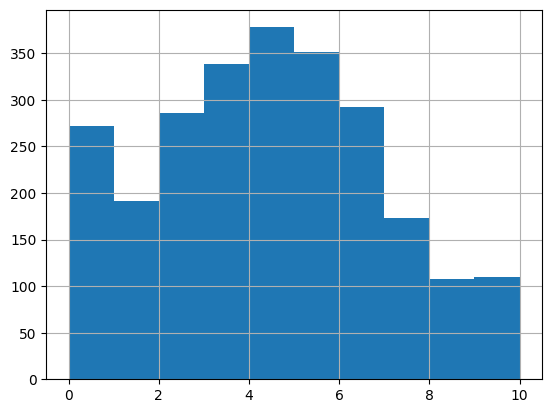

In [13]:
# Conferindo a distribuição do NPS
df['nps_score'].hist()

In [14]:
df['nps_score'].value_counts()

,count
nps_score,
0.0,158
4.5,49
4.9,44
3.9,44
3.4,42
...,...
9.5,6
9.0,5
9.8,4


Se comparado com uma curva de distribuição normal o NPS tem um número expressivo de valores 0. Necesssário analisar se são valores que vieram de resposta *default* ou se representam de fato a insatisfação do cliente.
Também está descrito como valor com decimais, fato que foge a metodologia do NPS. Vamos criar uma nova variável para armazenar o valor do NPS sem os dígitos decimais.

##### Removendo o dígitos decimais do NPS

In [15]:
df['nps_score_int'] = df['nps_score'].astype(int)

In [16]:
df['nps_score_int'].value_counts()

,count
nps_score_int,
4,378
5,351
3,339
6,292
2,286
0,272
1,191
7,173
8,108


<Axes: >

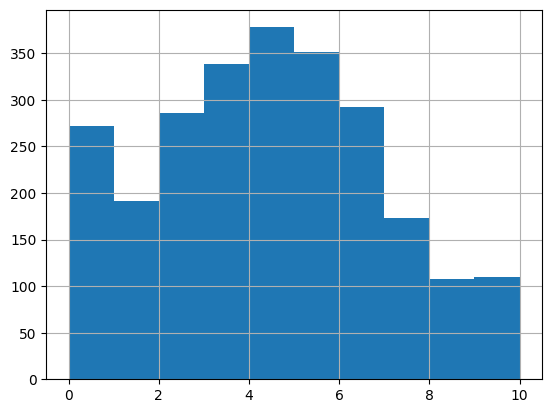

In [17]:
df['nps_score_int'].hist()

Se a fórmula for feita incluindo os NPS 0 o score fica na zona crítica, com mais detratores que promotores.

In [69]:
total = len(df)
promotores = len(df[df['nps_score_int'] >= 9])
detratores = len(df[df['nps_score_int'] <= 6])

nps = ((promotores - detratores) / total) * 100
print(f"NPS Calculado: {promotores} - {detratores} / {total} = {nps}%")

NPS Calculado: 110 - 2109 / 2500 = -79.96%


Para facilitar nossa análise, vamos criar uma nova variável categórica e classificar os clientes de acordo com o NPS por Detratores, Passivos e Promotores.

In [19]:
bins = [-1, 6, 8, 10]
labels = ['Detractor', 'Passive', 'Promoter']

# Criar a nova coluna 'nps_segment'
df['nps_segment'] = pd.cut(df['nps_score_int'], bins=bins, labels=labels)


In [20]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_score_int,nps_segment
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,6,Detractor
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,2,Detractor
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,4,Detractor
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,5,Detractor
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,6,Detractor


#### 2.2.6. Investigando viéses de subrepresentação de populações

<Axes: >

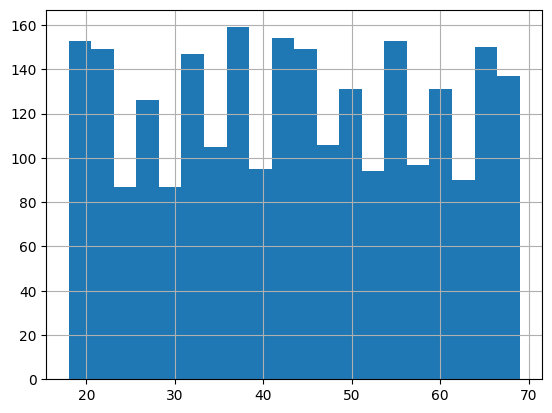

In [21]:
# Entendendo a distribuição por idade da base
df['customer_age'].hist(bins=20)

In [22]:
# Entendendo a distribuição por região da base
df['customer_region'].value_counts()

,count
customer_region,
Sul,521
Sudeste,520
Norte,506
Nordeste,485
Centro-Oeste,468


A base é bem equilibrada na distribuição de idade e região. Evitando viéses nessas dimensões.



---



#### 2.2.7. Análise de Correlação com NPS Score

Para identificar os fatores mais críticos para satisfação, vamos calcular a matriz de correlação do dataset e focar na `nps_score`.](https://)

In [23]:
# Matriz de correlação do dataset com foco em nps_score
correlation_matrix = df.corr(numeric_only=True)
nps_correlation = correlation_matrix['nps_score_int'].sort_values(ascending=False)
display(nps_correlation)

,nps_score_int
nps_score_int,1.000000
nps_score,0.992712
repeat_purchase_30d,0.586478
csat_internal_score,0.560912
order_value,0.035133
delivery_attempts,0.026449
discount_value,0.023890
payment_installments,0.018946
order_id,0.016283
customer_id,0.016283


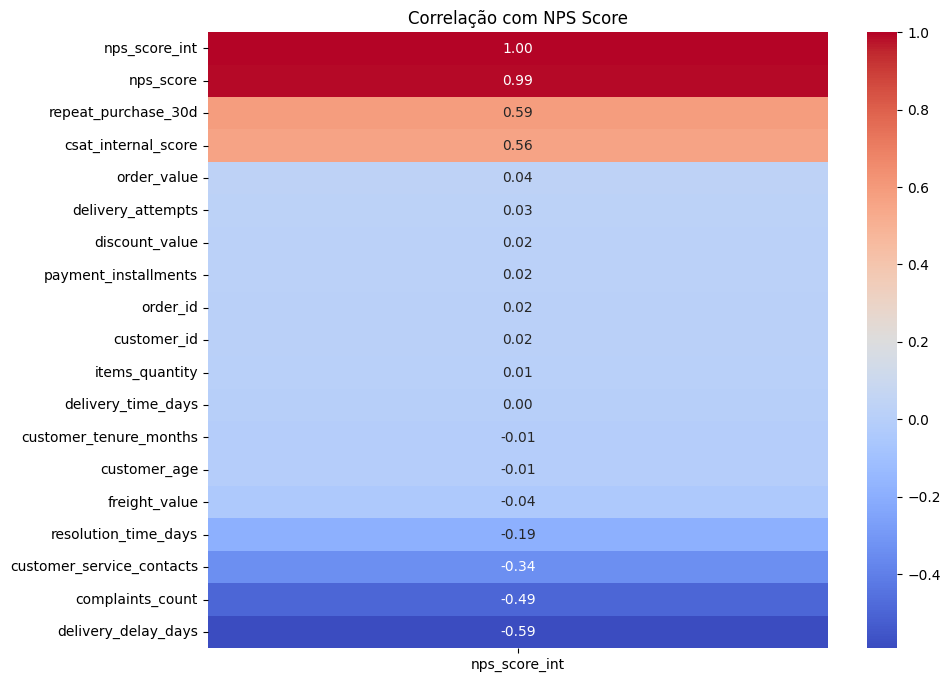

In [24]:
# Visualização da Correlação com NPS Score
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['nps_score_int']].sort_values(by='nps_score_int', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação com NPS Score')
plt.show()

No eixo positivo, `repeat_purchase_30d` tem uma correlação expressiva, porém é uma variável com *Leakage* na base. O dado só é coletado depois da compra e do registro de NPS pelo cliente e não pode nos ajudar a investigar a satisfação durante o processo. Assim como `csat_internal_score`que também deve contar com variáveis pós-experiência.

Já no eixo negativo, `customer_service_contacts`, `complaints_count` e `delivery_delay_days` representam variáveis que possivelmente estão afetando a experiência do cliente e diminuindo o NPS.

##### 2.2.7.1. Número de contatos do cliente com o atendimento



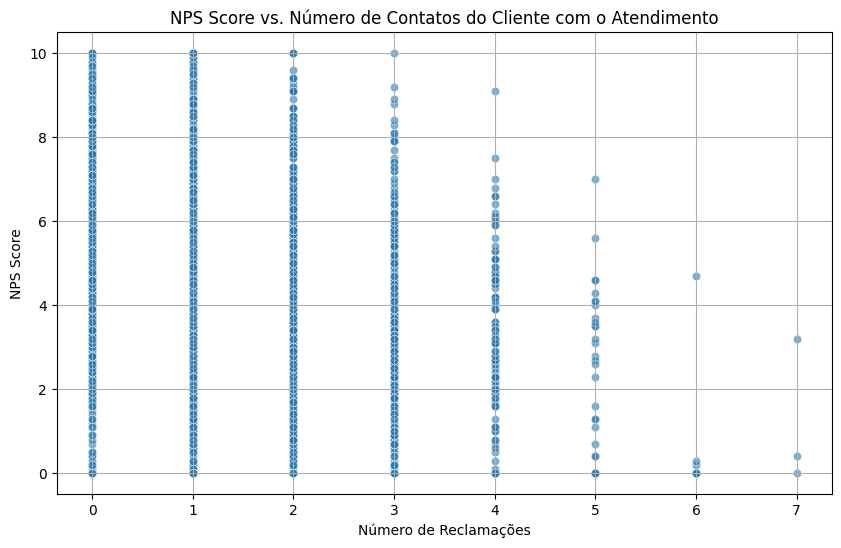

In [25]:
# Número de contatos com o atendimento tem relação com NPS?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_service_contacts', y='nps_score', data=df, alpha=0.6)
plt.title('NPS Score vs. Número de Contatos do Cliente com o Atendimento')
plt.xlabel('Número de Reclamações')
plt.ylabel('NPS Score')
plt.grid(True)
plt.show()

O número de `customer_service_contacts` (contatos com o atendimento ao cliente) apresenta uma correlação negativa com o NPS. Isso sugere que, quanto mais vezes um cliente precisa entrar em contato com o atendimento, menor tende a ser a sua satisfação e, consequentemente, o seu NPS. Clientes que precisam de muita assistência podem estar enfrentando problemas que diminuem a probabilidade de recomendarem a empresa.

##### 2.2.7.2. Número de reclamações registradas pelo cliente

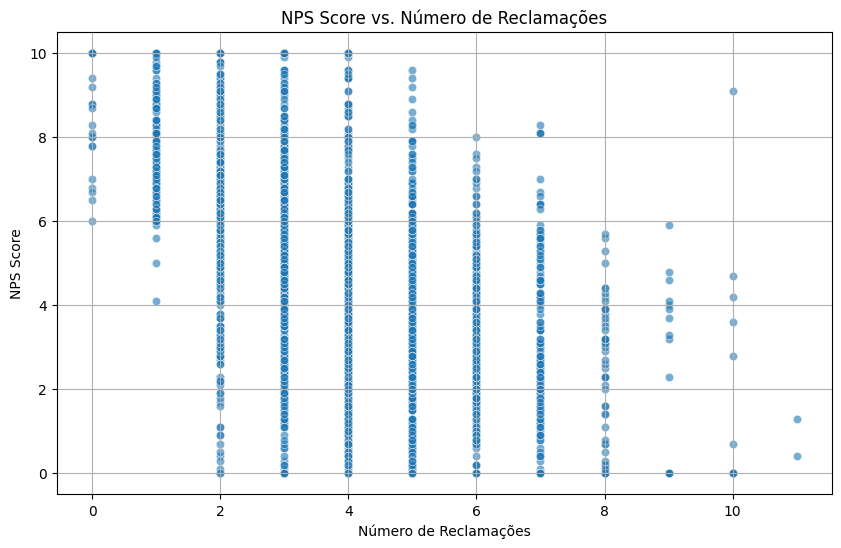

In [26]:
# Número de reclamações tem relação com nps?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='complaints_count', y='nps_score', data=df, alpha=0.6)
plt.title('NPS Score vs. Número de Reclamações')
plt.xlabel('Número de Reclamações')
plt.ylabel('NPS Score')
plt.grid(True)
plt.show()

A variável `complaints_count` apresenta uma correlação negativa com o `nps_score`. Isso indica que, à medida que o número de reclamações aumenta, o NPS tende a diminuir. Clientes com mais reclamações são, em média, menos propensos a recomendar a empresa, impactando negativamente o score.

Este é um fator crítico para a satisfação do cliente, pois um alto volume de reclamações sinaliza problemas na experiência que transformam potenciais promotores em detratores.

##### 2.2.7.3. Dias de atraso na entrega

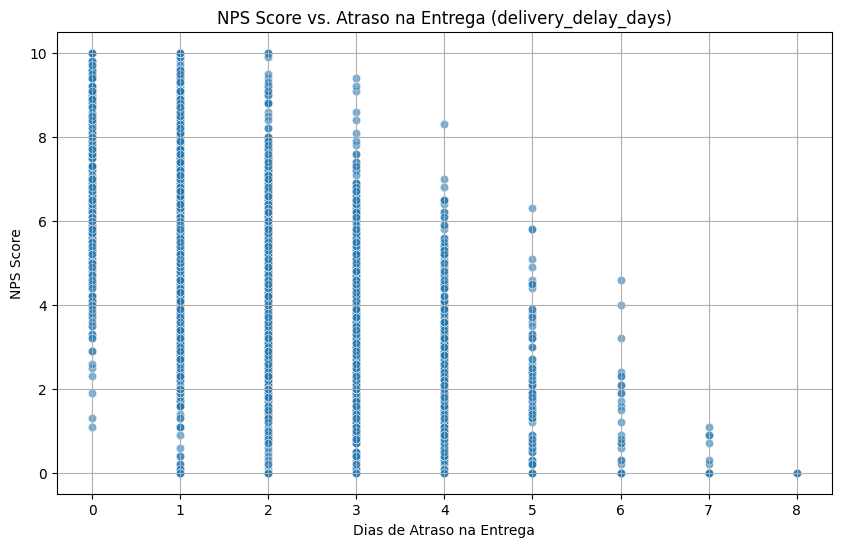

In [27]:
# Atraso na entrega tem relação com nps?
# Visualizando a relação entre atraso na entrega e o nps
plt.figure(figsize=(10, 6))
sns.scatterplot(x='delivery_delay_days', y='nps_score', data=df, alpha=0.6)
plt.title('NPS Score vs. Atraso na Entrega (delivery_delay_days)')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('NPS Score')
plt.grid(True)
plt.show()

A correlação negativa entre `delivery_delay_days` e `nps_score` sugere que atrasos na entrega afetam a satisfação do cliente. Clientes que experimentam entregas atrasadas tendem a dar notas de NPS mais baixas, o que pode transformá-los em detratores.

#### 2.2.8. Hipóteses Iniciais
Os fatores mais críticos para a satisfação são:
1. dias de atraso na entrega;
2. número de reclamações registradas pelo cliente;
3. número de contatos com o atendimento ao cliente.

---

#### 2.2.9. O “ponto de ruptura” na experiência do cliente

Qual valor faz o cliente passar de Promotor a Passivo ou mesmo Detrator?

##### 2.2.9.1. Número de contatos do cliente com o atendimento

In [28]:
print(df.groupby('nps_segment', observed=True)['customer_service_contacts'].mean())

nps_segment
Detractor    1.632053
Passive      1.007117
Promoter     0.672727
Name: customer_service_contacts, dtype: float64


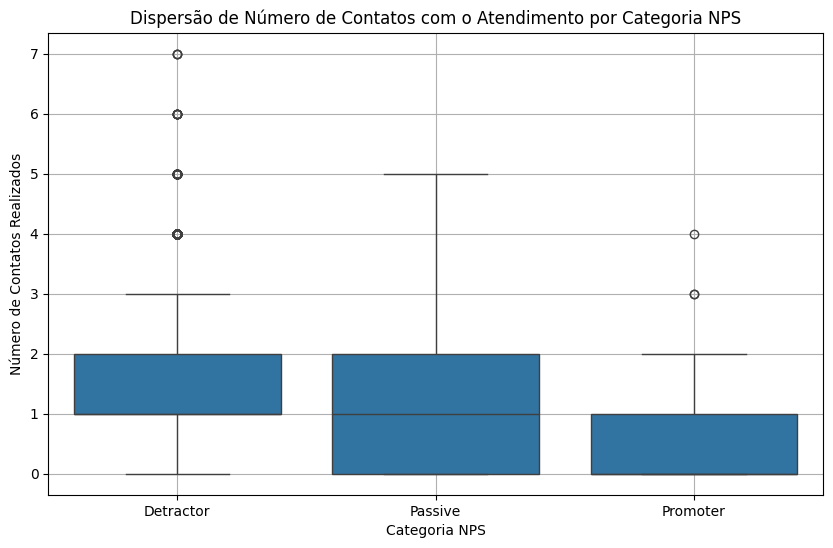

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nps_segment', y='customer_service_contacts', data=df, order=['Detractor', 'Passive', 'Promoter'])
plt.title('Dispersão de Número de Contatos com o Atendimento por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Número de Contatos Realizados')
plt.grid(True)
plt.show()

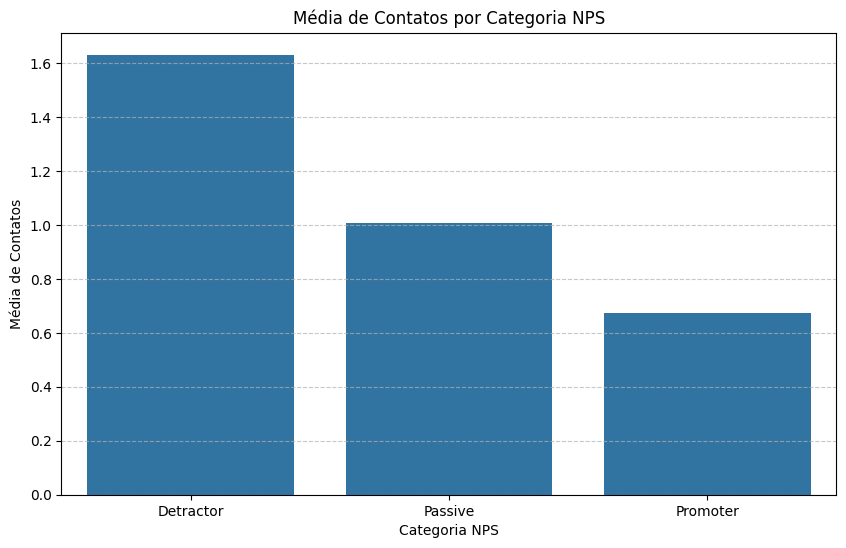

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='nps_segment', y='customer_service_contacts', data=df.groupby('nps_segment', observed=True)['customer_service_contacts'].mean().reset_index(), order=['Detractor', 'Passive', 'Promoter'])
plt.title('Média de Contatos por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Média de Contatos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Contatos com o Atendimento (customer_service_contacts): Da mesma forma, os 'Detratores' tendem a ter um número mais elevado de contatos com o serviço de atendimento ao cliente. Um possível "ponto de ruptura" pode ser observado quando o cliente precisa **entrar em contato 1 ou mais vezes**, indicando uma experiência frustrante que impacta negativamente o NPS.

##### 2.2.9.2. Número de reclamações registradas pelo cliente

In [30]:
print(df.groupby('nps_segment', observed=True)['complaints_count'].mean())

nps_segment
Detractor    4.442390
Passive      2.693950
Promoter     2.272727
Name: complaints_count, dtype: float64


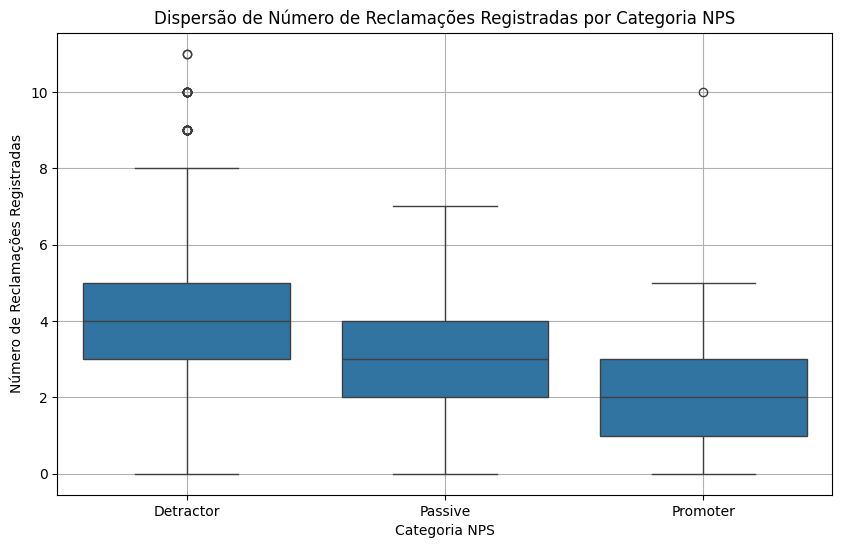

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nps_segment', y='complaints_count', data=df, order=['Detractor', 'Passive', 'Promoter'])
plt.title('Dispersão de Número de Reclamações Registradas por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Número de Reclamações Registradas')
plt.grid(True)
plt.show()

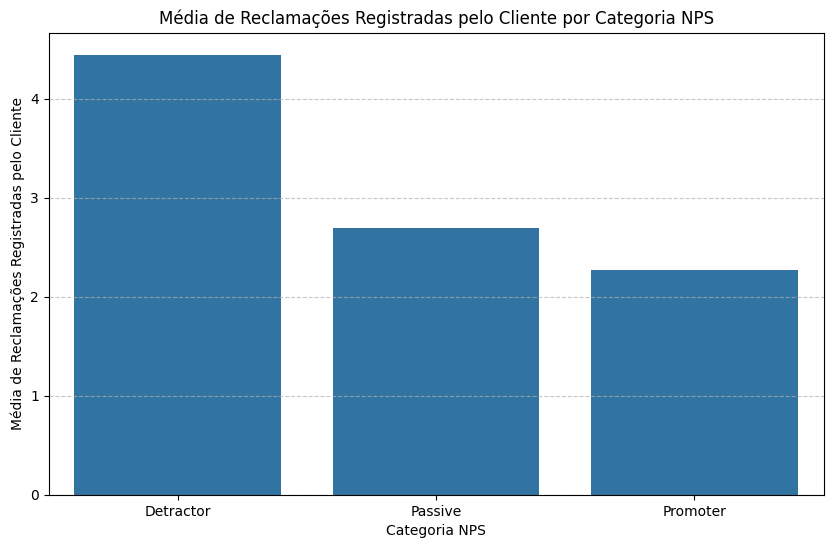

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='nps_segment', y='complaints_count', data=df.groupby('nps_segment', observed=True)['complaints_count'].mean().reset_index(), order=['Detractor', 'Passive', 'Promoter'])
plt.title('Média de Reclamações Registradas pelo Cliente por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Média de Reclamações Registradas pelo Cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Número de Reclamações (complaints_count): Clientes classificados como 'Detratores' consistentemente apresentam um número médio de reclamações significativamente maior do que 'Passivos' e 'Promotores'. O "ponto de ruptura" pode estar em torno **de 3 a 4 reclamações**, onde a probabilidade de um cliente se tornar um detrator aumenta consideravelmente.

##### 2.2.9.3. Dias de atraso na entrega

In [32]:
print(df.groupby('nps_segment', observed=True)['delivery_delay_days'].mean())

nps_segment
Detractor    2.414889
Passive      1.053381
Promoter     0.718182
Name: delivery_delay_days, dtype: float64


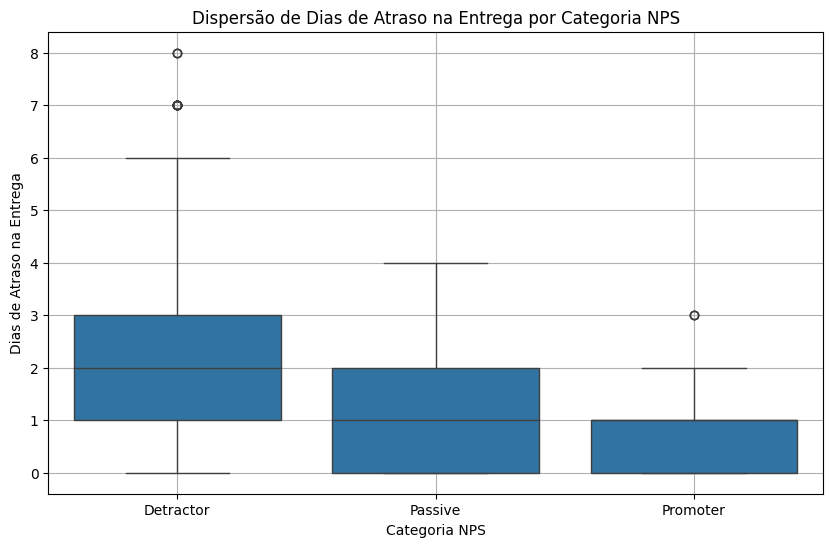

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nps_segment', y='delivery_delay_days', data=df, order=['Detractor', 'Passive', 'Promoter'])
plt.title('Dispersão de Dias de Atraso na Entrega por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Dias de Atraso na Entrega')
plt.grid(True)
plt.show()

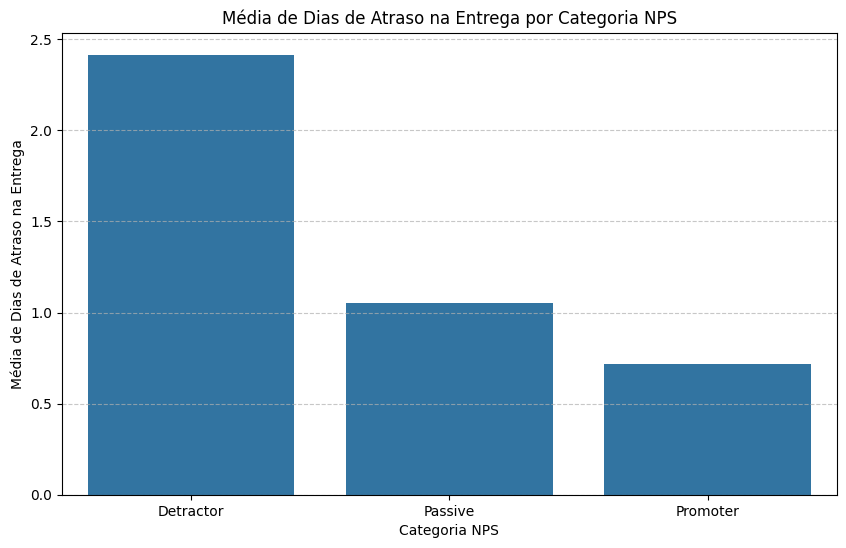

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='nps_segment', y='delivery_delay_days', data=df.groupby('nps_segment', observed=True)['delivery_delay_days'].mean().reset_index(), order=['Detractor', 'Passive', 'Promoter'])
plt.title('Média de Dias de Atraso na Entrega por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Média de Dias de Atraso na Entrega')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Atraso na Entrega (delivery_delay_days): Atrasos nas entregas são um fator crítico. Clientes com NPS baixo frequentemente reportam mais dias de atraso. Embora não haja um número mágico, **a partir de 1 ou 2 dias de atraso**, já podemos observar uma tendência de queda no NPS, com Detratores apresentando consistentemente atrasos maiores.

---


#### 2.1.10. Perfil do cliente por NPS

Primeiro, vamos analisar se a idade do cliente (`customer_age`) tem alguma relação com o seu segmento de NPS.

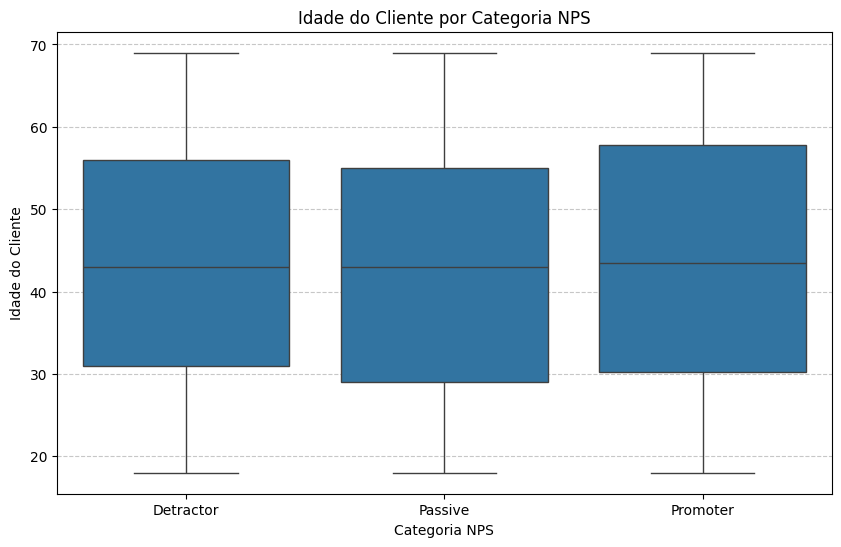

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nps_segment', y='customer_age', data=df, order=['Detractor', 'Passive', 'Promoter'])
plt.title('Idade do Cliente por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Idade do Cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

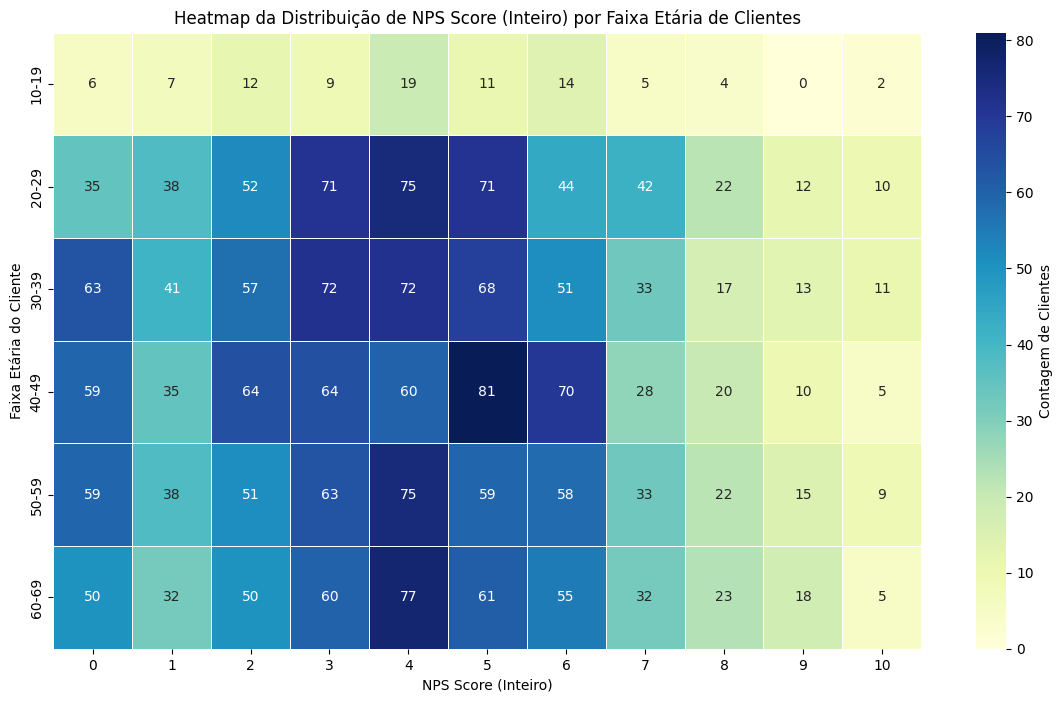

In [45]:
df['customer_age_band'] = pd.cut(df['customer_age'], bins=range(10, 80, 10), right=False, labels=[f'{i}-{i+9}' for i in range(10, 70, 10)])
pivot_table = df.pivot_table(index='customer_age_band', columns='nps_score_int', aggfunc='size', fill_value=0, observed=False)
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Contagem de Clientes'})
plt.title('Heatmap da Distribuição de NPS Score (Inteiro) por Faixa Etária de Clientes')
plt.xlabel('NPS Score (Inteiro)')
plt.ylabel('Faixa Etária do Cliente')
plt.show()

Agora, verificar se o tempo de relacionamento do cliente com a empresa (`customer_tenure_months`) influencia o seu segmento de NPS.

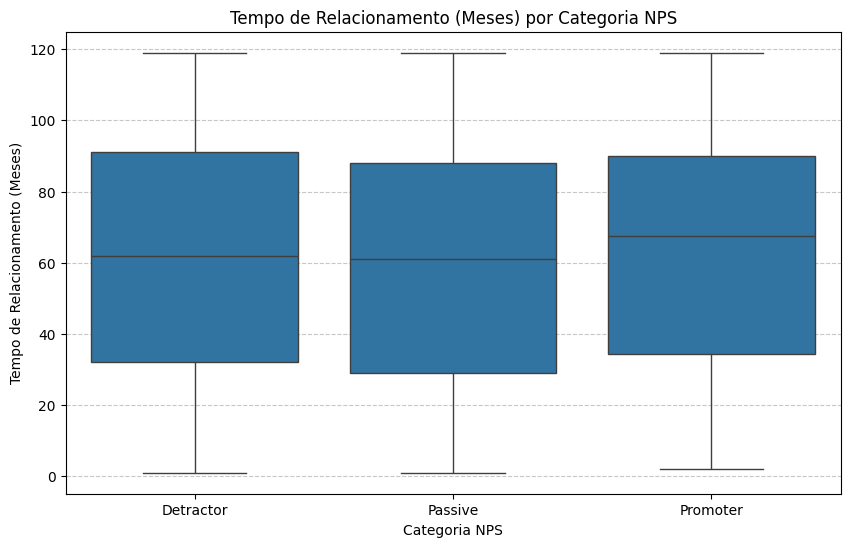

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nps_segment', y='customer_tenure_months', data=df, order=['Detractor', 'Passive', 'Promoter'])
plt.title('Tempo de Relacionamento (Meses) por Categoria NPS')
plt.xlabel('Categoria NPS')
plt.ylabel('Tempo de Relacionamento (Meses)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Por fim, vamos investigar se a região geográfica do cliente (`customer_region`) tem alguma influência na distribuição dos segmentos de NPS.

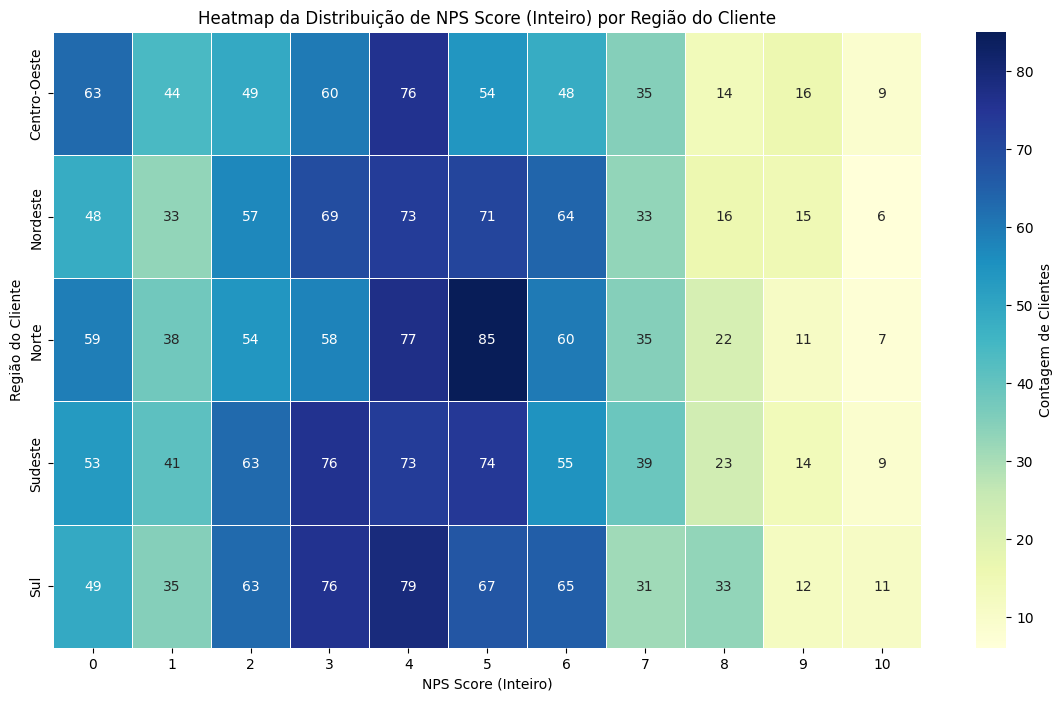

In [42]:
pivot_table = df.pivot_table(index='customer_region', columns='nps_score_int', aggfunc='size', fill_value=0)
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Contagem de Clientes'})
plt.title('Heatmap da Distribuição de NPS Score (Inteiro) por Região do Cliente')
plt.xlabel('NPS Score (Inteiro)')
plt.ylabel('Região do Cliente')
plt.show()

Sobre o perfil de cliente que tende a ter o NPS mais baixo ou alto, a base tem uma **distribuição bem equilibrada, não sendo possível apontar um perfil com maior resposta negativa ou positiva com segurança**.



---



## 3. Data Preparation

Nessa etapa vamos organizar os dados para o nosso modelo. Começando pela Variável Alvo, o Score NPS.

### 3.1. Definição da Variável Alvo para Classificação

In [46]:
# Criar a variável alvo binária 'is_promoter'
# Promotores (NPS 9-10) = 1, Não-Promotores (NPS 0-8) = 0
df['is_promoter'] = df['nps_score_int'].apply(lambda x: 1 if x >= 9 else 0)

# Verificar a distribuição da nova variável alvo
print("Distribuição da variável alvo 'is_promoter':")
print(df['is_promoter'].value_counts())
print("\nProporção:")
print(df['is_promoter'].value_counts(normalize=True))


Distribuição da variável alvo 'is_promoter':
is_promoter
0    2390
1     110
Name: count, dtype: int64

Proporção:
is_promoter
0    0.956
1    0.044
Name: proportion, dtype: float64


### 3.2. Remoção de Leakage e Identificadores

`nps_score`, `nps_score_int`, `nps_segment` são as variáveis alvo e suas derivações.

`repeat_purchase_30d`, `csat_internal_score` são variáveis que podem apresentar leakage, já que são medidas somente após o cliente informar o NPS.

`customer_id`, `order_id` são identificadores únicos e não são relevantes no nosso modelo.

In [56]:
# Lista de colunas a serem removidas
drop_columns = [
    'customer_id',
    'order_id',
    'nps_score',
    'nps_score_int',
    'nps_segment',
    'repeat_purchase_30d',
    'csat_internal_score',
    'customer_age_band'
]

df_model = df.drop(columns=drop_columns)

print(f"Colunas após remoção: {df_model.columns.tolist()}")

Colunas após remoção: ['customer_age', 'customer_region', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count', 'is_promoter']


### 3.3. Codificação de Variáveis Categóricas (One-Hot Encoding)

Para que as máquinas possa processar o variável `customer_region` vamos utilizar a técnica de One-Hot Enconding

In [57]:
# Aplicar One-Hot Encoding à variável 'customer_region'
df_model = pd.get_dummies(df_model, columns=['customer_region'], drop_first=True)

print("Colunas após One-Hot Encoding:")
print(df_model.columns.tolist())

Colunas após One-Hot Encoding:
['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count', 'is_promoter', 'customer_region_Nordeste', 'customer_region_Norte', 'customer_region_Sudeste', 'customer_region_Sul']


### 3.4. Separação de Features (X) e Target (y)

In [58]:
# Separar a variável alvo (y) das features (X)
X = df_model.drop(columns=['is_promoter'])
y = df_model['is_promoter']

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (2500, 17)
Dimensões de y: (2500,)


### 3.5. Divisão dos Dados em Conjuntos de Treino e Teste

In [60]:
from sklearn.model_selection import train_test_split

# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
# Usar stratify=y para manter a mesma proporção de promotores/não-promotores em ambos os conjuntos
# random_state para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensões do conjunto de treino (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Dimensões do conjunto de teste (X_test, y_test): {X_test.shape}, {y_test.shape}")

print("\nProporção de promotores no treino:")
print(y_train.value_counts(normalize=True))
print("\nProporção de promotores no teste:")
print(y_test.value_counts(normalize=True))

Dimensões do conjunto de treino (X_train, y_train): (2000, 17), (2000,)
Dimensões do conjunto de teste (X_test, y_test): (500, 17), (500,)

Proporção de promotores no treino:
is_promoter
0    0.956
1    0.044
Name: proportion, dtype: float64

Proporção de promotores no teste:
is_promoter
0    0.956
1    0.044
Name: proportion, dtype: float64


### 3.6. Escalonamento de Features Numéricas

Para uniformizar a escala e melhorar a convergência do algorítimo vamos executar o escalonamento dos dados.

In [61]:
from sklearn.preprocessing import StandardScaler

# Inicializar o StandardScaler
scaler = StandardScaler()

# Identificar colunas numéricas para escalonamento
# Excluir as colunas dummy criadas pelo One-Hot Encoding e a target, se ainda estiver em X
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Escalonar apenas as colunas numéricas nos conjuntos de treino e teste
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Features numéricas escalonadas com sucesso!")

# Treinar e avaliar o modelo novamente com os dados escalonados.
# Este passo será executado na célula de Modelagem.


Features numéricas escalonadas com sucesso!


## 4. Modeling

### 4.1. Treinamento do Modelo de Classificação (Regressão Logística) com dados escalonados

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Inicializar e treinar o modelo de Regressão Logística
# max_iter aumentado para garantir a convergência
model = LogisticRegression(random_state=42, max_iter=2000) # Aumentando max_iter para garantir convergência após escalonamento
model.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso com dados escalonados!")

Modelo de Regressão Logística treinado com sucesso com dados escalonados!


### 4.1. Treinamento do Modelo de Classificação (Regressão Logística)

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Inicializar e treinar o modelo de Regressão Logística
# max_iter aumentado para garantir a convergência
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

Modelo de Regressão Logística treinado com sucesso!


### 4.2. Previsões no Conjunto de Teste

In [64]:
# Realizar previsões no conjunto de teste
y_pred = model.predict(X_test)

print("Previsões realizadas no conjunto de teste.")

Previsões realizadas no conjunto de teste.


## 5. Evaluation

### 5.1. Avaliação do Desempenho do Modelo


--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       478
           1       0.25      0.05      0.08        22

    accuracy                           0.95       500
   macro avg       0.60      0.52      0.53       500
weighted avg       0.93      0.95      0.94       500


--- Matriz de Confusão ---


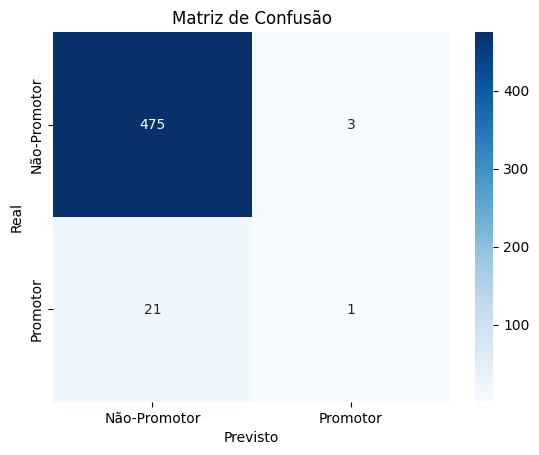

In [65]:
# Gerar o relatório de classificação
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# Gerar a matriz de confusão
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não-Promotor', 'Promotor'], yticklabels=['Não-Promotor', 'Promotor'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

### 5.1.1. Não-Promotores
- Quando o modelo prevê um não-promotor ele está correto 96% das vezes.
- O modelo identificou corretamente 99% dos não-promotores reais.
### 5.1.2. Promotores
- Quando o modelo prevê um promotor, ele está correto apenas 25% das vezes.
- O modelo identificou apenas 5% dos promotores reais.



5.2. Confusão
- Verdadeiros Negativos: O modelo previu corretamente 475 não promotores.
- Falsos Positivos: O modelo previu 3 promotores que eram na verdade não-promotores.
- Falsos Negativos: O modelo previu 21 não-promotores que eram na verdade promotores.
- Verdadeiros Positivos: O modelo previu corretamente 1 promotor.

Apesar da baixa precisão em acertar clientes que são realmente promotores, o modelo se mostra efetivo para identificar não-promotores e apontar oportunidades de ação.
O custo de negócio associado a engajar com promotores falsamente marcados como não-promotores é baixo. Já a recompensa de agir em casos de não-promotores corretamente identificados pode gerar uma grande melhoria no NPS.

##6. Deployment

O modelo pode ser utilizado em uma **API** consumida diretamente pelo CRM do e-commerce. O sistema poderia dispar ações automaticamente ao identificar um não-promotor.
Outro solução possível é a criação de um **painel de BI** para monitoramento contínuo da base pelos gestores e busca de novas soluções.

Seja qual for a solução implementada, o modelo deve ter documentação, um canal de feedback, ser revisto e retestado com o tempo e crescimento da base. Garantindo um ciclo sustentável e confiáveis de informações para a tomada de decisões.

## 7. Conclusão

A Ciência de Dados pode ajudar a empresa a ter proatividade na relação com o cliente. Em vez de esperar fatores operacionais atrapalhem a experiência e só depois coletar índices de satisfação, é possível criar um modelo que alerte pontos críticos da relação para traçar estratégias e agir antes que o impacto ocorra.

Um modelo preditivo funciona como um radar, analisando os sinais que o cliente deixa durante a jornada (atrasos, contatos com o SAC, valor do frete) para nos avisar sobre a satisfação dele antes de aplicarmos qualquer pesquisa.

### 7.1. Abordagens possíveis de modelos preditivos:
#### 7.1.1. Modelo de Regressão (O "Termômetro"):
Tenta prever a nota exata que o cliente dará, de 0 a 10
- É como um termômetro que nos diz a temperatura precisa. Embora detalhado, na prática operacional, saber se o cliente dará nota 2,3 ou 2,7 muda pouco a nossa ação.

#### 7.1.2. Modelo de Classificação (O "Semáforo"):
Em vez de uma nota quebrada, ele coloca o cliente em "baldes" ou categorias, como Satisfeito (Promotor) ou Insatisfeito (Não-Promotor)
- É como um semáforo: se o modelo acende a luz vermelha para um pedido, sabemos que precisamos agir imediatamente.

Para a operação da empresa do caso, recomendo um **modelo de classificação** para separar os clientes em dois grupos: Promotores (notas 9-10) e Não-Promotores (notas 0-8).

### 7.2. Ponto de vista do negócio:
- **Ação Imediata:** É muito mais fácil para a equipe de atendimento receber uma lista de "Clientes em Risco" do que tentar interpretar notas decimais. Podemos criar regras claras: "Se o modelo marcar como risco, o SAC entra em contato em até 2 horas";

- **Priorização de Recursos:** Nem toda insatisfação custa o mesmo. Podemos cruzar a previsão de "Não-Promotor" com o order_value (valor do pedido) ou customer_tenure_months (tempo de casa) para priorizar o resgate dos nossos clientes mais valiosos.

- **Redução de Perdas (ROI):** Ao antecipar um detrator, evitamos o "boca a boca" negativo e aumentamos a chance de recompra (repeat_purchase_30d), gerando um retorno financeiro direto sobre o investimento no projeto.

### 7.3. Ponto de vista técnico:
- Foco no que importa (Recall): Tecnicamente, em problemas de satisfação, o erro mais caro é o "Falso Positivo" (achar que o cliente está bem, quando na verdade ele vai dar uma nota baixa)

- Modelos de classificação nos permitem ajustar a sensibilidade para garantir que capturemos o máximo de clientes insatisfeitos, mesmo que isso gere alguns alarmes falsos para revisão

- Robustez dos Dados: O NPS, por natureza, não segue uma distribuição "normal" (as pessoas tendem a dar notas muito altas ou muito baixas)
. Modelos de classificação lidam melhor com esse comportamento de extremos do que as regressões lineares simples

- Explicabilidade: Modelos de classificação (como as árvores de decisão) conseguem nos dizer claramente o porquê daquele alerta: "Este cliente foi classificado como risco porque teve 2 tentativas de entrega falhas e um atraso superior a 3 dias".

### 7.4. Apontamentos Finais
Ao adotar a classificação, transformamos dados operacionais (logística e atendimento) em uma ferramenta de gestão. Não estamos apenas tentando adivinhar uma nota; estamos construindo um sistema de alerta antecipado para que a empresa possa intervir na jornada do cliente, garantir sua lealdade e proteger seu faturamento.